## 🟩 **DAY 2 — 2 HRS**

### 1. **GENAI — 60 MIN**
- [ ] BERT vs GPT
- [ ] Encoder vs Decoder
- [ ] Pre-training vs Fine-tuning
- [ ] Hugging Face model loading

### 2. **DSA — 45 MIN**
- [ ] Arrays: Traversal & Searching
- [ ] 2 Easy problems

### 3. **PRACTICE — 15 MIN**
- [ ] Load one HF model
- [ ] Run inference

<br>

### **BERT vs GPT**

**1. BERT (Bidirectional Encoder Representations from Transformers)**
* **Architecture:** Encoder-only.
* **How it reads:** **Bidirectional**. It looks at the entire sentence all at once (left-to-right and right-to-left) to understand the deep context of every word based on its surroundings.
* **Training Method:** Masked Language Modeling (MLM). It is trained by hiding 15% of the words in a sentence and forcing the model to guess the missing words (like a fill-in-the-blank test).
* **Best for (NLU):** Natural Language *Understanding*. Tasks where you need to analyze existing text, such as:
  * Sentiment Analysis
  * Text Classification
  * Named Entity Recognition
  * Extractive Question Answering

**2. GPT (Generative Pre-trained Transformer)**
* **Architecture:** Decoder-only.
* **How it reads:** **Unidirectional (Autoregressive)**. It reads left-to-right and cannot look ahead at future words.
* **Training Method:** Causal Language Modeling (Next-Word Prediction). It is trained by giving it a sequence of words and forcing it to predict the very next word.
* **Best for (NLG):** Natural Language *Generation*. Tasks where you need to create new text, such as:
  * Chatbots and Conversational AI
  * Story/Code writing
  * Summarization
  * Translation

**Quick Comparison:**
* **Transformer Part:** BERT uses the Encoder, GPT uses the Decoder.
* **Attention:** BERT is Bidirectional, GPT is Unidirectional.
* **Core Goal:** BERT is for contextual understanding, GPT is for text generation.
* **Training Task:** BERT guesses hidden words, GPT predicts the next word.
* **Primary Domain:** BERT is for NLU, GPT is for NLG.

<br>

```text
===================================================
             THE TRANSFORMER FAMILY
===================================================

             [ Original Transformer ]
              (Encoder + Decoder)
              /                 \
             /                   \
            /                     \
  [ ENCODER ONLY ]               [ DECODER ONLY ]
  - Bidirectional                - Unidirectional
  - Reads text all at once       - Predicts next word
  - Good for Understanding (NLU) - Good for Generation (NLG)
  - e.g., BERT, RoBERTa          - e.g., GPT, Llama, Claude

===================================================
```

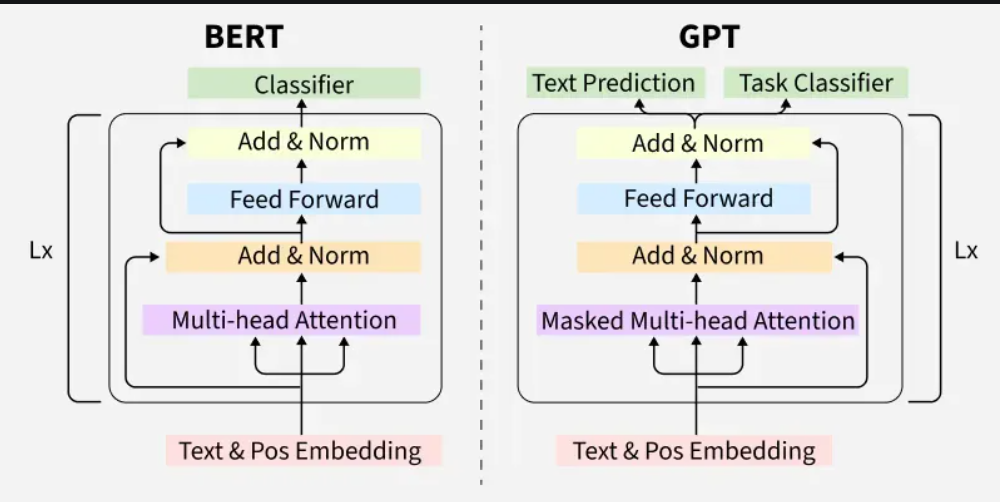

<br>

### **Encoder vs Decoder**

**1. Encoders**
* **Architecture:** Uses only the Encoder blocks of the Transformer.
* **Context Mechanism:** **Bidirectional**. It looks at the entire sequence all at once (left-to-right and right-to-left) to build a deep understanding of the context.
* **Best for (NLU):** Natural Language Understanding. These models excel at analyzing and categorizing existing text.
* **Common Tasks:** Sentiment analysis, spam detection, named entity recognition.
* **Examples:** BERT, RoBERTa, ALBERT.

**2. Decoders**
* **Architecture:** Uses only the Decoder blocks of the Transformer.
* **Context Mechanism:** **Unidirectional (Autoregressive)**. It only looks at the past (previous words) to predict the future (the next word). It uses "Masked Self-Attention" to hide future tokens during training.
* **Best for (NLG):** Natural Language Generation. These models excel at creating new text from scratch.
* **Common Tasks:** Chatbots, summarization, translation, coding assistants.
* **Examples:** GPT-4, Llama 3, Claude, Mistral.

<br>


```text
===================================================
             ENCODER VS DECODER MECHANICS
===================================================

[ ENCODER ] (Bidirectional)
Input:   The   cat   sat   on   the   mat
          ^     ^     ^     ^     ^     ^
          | \ / \ / \ / \ / \ / \ / \ / |
          |  X   X   X   X   X   X   X  | <-- Every word looks at
          | / \ / \ / \ / \ / \ / \ / \ |     EVERY other word
          v     v     v     v     v     v
Output:  Deep contextual understanding of the whole sentence.


[ DECODER ] (Unidirectional / Autoregressive)
Input:   The   cat   sat   on   the   mat   [?]
          |     |     |     |     |     |
          v     v     v     v     v     v
          \---->\---->\---->\---->\---->\---> "and"
                                              (Predicts next word)
          *Note: Only looks at past words. Future words are hidden (masked).*

===================================================

<br>

### **Pre-training vs Fine-tuning**

```text
======================================================================
           THE TWO-STEP LIFECYCLE OF A GENERATIVE AI MODEL
======================================================================

[ 1. PRE-TRAINING ] (The General Education)
  - Massive dataset (a large chunk of the internet).
  - Unsupervised/Self-supervised learning (predicting masked or next words).
  - Goal: Learn the structure, grammar, facts, and reasoning of the language.
  - Result: A "Base" model (e.g., `gpt2`, `Llama-2-7b`). It knows a lot but
    doesn't know how to act like an assistant yet.

                           |
                           v

[ 2. FINE-TUNING ] (The Specialized Degree)
  - Smaller, high-quality, labeled dataset (e.g., 10k QA pairs or reviews).
  - Supervised learning.
  - Goal: Teach the model a specific task or format (like answering questions
    politely or classifying spam).
  - Result: An "Instruct" or Task-Specific model (e.g., `gpt-3.5-turbo`,
    `distilbert-base-uncased-finetuned-sst-2-english`).
======================================================================
```

<br>

### **Hugging Face Model Loading**

Hugging Face uses **AutoClasses** to simplify loading models. Instead of manually importing specific architectures (like `BertModel` or `GPT2LMHeadModel`), you just use the generic `Auto` prefix, and the library automatically detects and loads the correct architecture, weights, and configurations based on the checkpoint name.

```text
======================================================================
               THE HUGGING FACE AUTO CLASS SYSTEM
======================================================================

[ CHECKPOINT NAME ] (e.g., "google-bert/bert-base-uncased")
       |
       v
[ AutoTokenizer ]   -------> Prepares text (turns words into number IDs)
       |
       v
[ AutoModelFor... ] -------> Loads the model with the right "Head" for
                             your specific task.

COMMON AUTOMODEL CLASSES:
- AutoModel                          : Base model only (returns raw embeddings)
- AutoModelForSequenceClassification : For NLU (Sentiment, Spam detection)
- AutoModelForCausalLM               : For NLG (Text generation, Chatbots)
- AutoModelForSeq2SeqLM              : For Translation, Summarization

======================================================================

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "gpt2" # or any model on the Hugging Face Hub

# 1. Load the Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Load the Model
model = AutoModelForCausalLM.from_pretrained(model_name)

# 3. Define prompt and tokenize
prompt = "Artificial Intelligence will change the future because"
inputs = tokenizer(prompt, return_tensors="pt")

# 4. Generate new text
output_ids = model.generate(
    **inputs,
    max_new_tokens=30,      # Generate 30 new tokens
    temperature=0.7,        # Randomness control
    do_sample=True,         # Enable sampling
    pad_token_id=tokenizer.eos_token_id
)

# 5. Decode output back to plain text
generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(generated_text)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Artificial Intelligence will change the future because it's so much more complex.

To understand how AI will change the future, let's try to understand what this change will mean for the




---






---



#### **PRATICE**

In [4]:
# ==========================================================
# 1. PRACTICE: ENCODER MODEL (Text Classification / Sentiment)
# ==========================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load a pre-trained Encoder model fine-tuned for sentiment analysis
encoder_name = "distilbert-base-uncased-finetuned-sst-2-english"
enc_tokenizer = AutoTokenizer.from_pretrained(encoder_name)
enc_model = AutoModelForSequenceClassification.from_pretrained(encoder_name)

# Input text to classify
sample_text = "I am really enjoying learning about GenAI and Transformers today!"
enc_inputs = enc_tokenizer(sample_text, return_tensors="pt")

# Run forward pass (no autoregressive generation needed for encoders)
with torch.no_grad():
    logits = enc_model(**enc_inputs).logits

# Extract label prediction
predicted_id = logits.argmax().item()
label = enc_model.config.id2label[predicted_id]

print(f"Input: \"{sample_text}\"")
print(f"Predicted Sentiment: {label}\n")


# ==========================================================
# 2. PRACTICE: DECODER MODEL (Sampling & Temperature Tuning)
# ==========================================================
# Using the GPT-2 model loaded earlier to see how temperature affects output
test_prompt = "The future of artificial intelligence is"
dec_inputs = tokenizer(test_prompt, return_tensors="pt")

print("--- Creative Generation (Temperature = 1.2) ---")
creative_output = model.generate(
    **dec_inputs,
    max_new_tokens=25,
    temperature=1.2,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(creative_output[0], skip_special_tokens=True))

print("\n--- Focused Generation (Temperature = 0.2) ---")
focused_output = model.generate(
    **dec_inputs,
    max_new_tokens=25,
    temperature=0.2,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(focused_output[0], skip_special_tokens=True))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Input: "I am really enjoying learning about GenAI and Transformers today!"
Predicted Sentiment: POSITIVE

--- Creative Generation (Temperature = 1.2) ---
The future of artificial intelligence is a topic of speculation for decades — but what if they become the dominant problem right now? Now, researchers at MIT's Jet

--- Focused Generation (Temperature = 0.2) ---
The future of artificial intelligence is in the hands of the people.

The future of artificial intelligence is in the hands of the people.

The




---





---



#### **PRATICE**

In [8]:
##########
#  BERT `#
##########

#IMPORT LIBRARIES
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
import torch

#TOKENIZER
tokenizer = AutoTokenizer.from_pretrained("SamLowe/roberta-base-go_emotions")

#MODEL
model = AutoModelForSequenceClassification.from_pretrained("SamLowe/roberta-base-go_emotions")

#TEXT
sentence = "I can't believe I finally solved this bug after 4 hours!"

#FOWARD PASS
with torch.no_grad():
  outputs = model(**res)

#EXTRACT PREDICTED EMOTION
logits = outputs.logits
predicted_ids = logits.argmax().item()
predicted_emotion = model.config.id2label[predicted_ids]

#PRINT
print(f"Sentence: \"{sentence}\"")
print(f"Predicted Emotion: {predicted_emotion}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence: "I can't believe I finally solved this bug after 4 hours!"
Predicted Emotion: surprise


<br>

In [17]:
##########
#  GPT `#
##########

#MODEL
model_pkt = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

#TOKENIZER
token = AutoTokenizer.from_pretrained(model_pkt)

#MODEL
ai = AutoModelForCausalLM.from_pretrained(model_pkt)

#DATA
prompt = "Explain what an API is in one simple sentence"

#TOKENIZE IT
pack = token(prompt, return_tensors='pt')

#GENERATE THE TEXT .generate()

mod = ai.generate(
    **pack,
    max_new_tokens=50,
    temperature=1.2,
    do_sample=True,
    pad_token_id=token.eos_token_id
)

# EXTRACT & DECODE ONLY THE NEW RESPONSE
input_len = pack["input_ids"].shape[1]
response_ids = mod[0][input_len:]
clean_text = token.decode(response_ids, skip_special_tokens=True).strip()

print("--- AI RESPONSE ---")
print(clean_text)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- AI RESPONSE ---
: "A software-defined network is an architectural model that enables network service providers to optimize and automate the provisioning and management of software as a service capabilities, including mobile and cloud back-end application platform services, at a fraction of
